In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2
import random
import shutil
!nvidia-smi
!pip install torch torchvision torchaudio
!pip install ultralytics
!pip install thop ptflops
!pip install opencv-python
!pip install codecarbon
import warnings
warnings.filterwarnings('ignore')
from codecarbon import EmissionsTracker
from ultralytics import YOLO, RTDETR
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
torch.backends.cudnn.benchmark = True
torch.cuda.empty_cache()
import shutil
from torch.utils.data import DataLoader

Wed Apr 15 15:44:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
shutil.copytree("/kaggle/input/datasets/vaibhavdatascience/cottenweed/cottenweed",
                "/kaggle/working/data",
               dirs_exist_ok = True)

'/kaggle/working/data'

In [18]:
teacher = YOLO('/kaggle/input/datasets/vaibhavdatascience/1012mc-yolo11n/yolo_11n_1012_mc.yaml').load('yolo11n.pt')

teacher.train(data='/kaggle/input/datasets/vaibhavdatascience/c-yaml/cottenweed.yaml',
             epochs =25,
             imgsz=640,
             device='0,1')

WARNING ⚠️ no model scale passed. Assuming scale='n'.
Transferred 448/499 items from pretrained weights
Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/vaibhavdatascience/c-yaml/cottenweed.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=

In [22]:
student = YOLO('/kaggle/input/datasets/vaibhavdatascience/yolo11n-512mc/yolo11n_512_mc.yaml').load('yolo11n.pt')

Transferred 301/499 items from pretrained weights


In [23]:
student.train(data='/kaggle/input/datasets/vaibhavdatascience/c-yaml/cottenweed.yaml',
             epochs =1,
             imgsz=640,
             device='0,1')

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/vaibhavdatascience/c-yaml/cottenweed.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/datasets/vaibhavdatascience/yolo11n-512mc/yolo

In [2]:
device = 'cuda'
teacher = YOLO('/kaggle/working/runs/detect/train10/weights/best.pt').model.eval().to(device)
student = YOLO("/kaggle/working/runs/detect/train12/weights/best.pt").load('yolo11n.pt').to(device)

Transferred 301/499 items from pretrained weights


In [3]:
import copy
from ultralytics.utils import DEFAULT_CFG, IterableSimpleNamespace

# 1. Load the absolute defaults (this includes box=7.5, cls=0.5, mosaic=1.0, etc.)
# We use copy to avoid modifying the global default object
hyp = copy.copy(DEFAULT_CFG)

# 2. If you want to ensure it's a SimpleNamespace (which your code was expecting)
if not isinstance(hyp, IterableSimpleNamespace):
    hyp = IterableSimpleNamespace(**hyp)

# 3. Double-check the critical ones you were missing
print(f"Verified Box Gain: {hyp.box}")      # Should be 7.5
print(f"Verified Mosaic: {hyp.mosaic}")    # Should be 1.0
print(f"Verified Mixup: {hyp.mixup}")      # Should be 0.0
print(f"Verified Mixup: {hyp.dfl}")
print(f"Verified Mixup: {hyp.cls}")

Verified Box Gain: 7.5
Verified Mosaic: 1.0
Verified Mixup: 0.0
Verified Mixup: 1.5
Verified Mixup: 0.5


In [7]:
from ultralytics.data.dataset import YOLODataset
from ultralytics.data.utils import check_det_dataset
from torch.utils.data import DataLoader
from types import SimpleNamespace

# 1. Load your data config (the .yaml file)
data_info = check_det_dataset('/kaggle/input/datasets/vaibhavdatascience/c-yaml/cottenweed.yaml')

hyp_namespace = hyp

# 2. Re-run the dataset initialization
train_dataset = YOLODataset(
    data=data_info,         
    img_path=data_info['train'], 
    imgsz=640,
    augment=True, 
    hyp=hyp_namespace,   # <--- Pass the Namespace, not the dict
    task='detect'
)

# 3. Create your DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    collate_fn=train_dataset.collate_fn # CRITICAL: YOLO uses a custom collate
)

Fast image access ✅ (ping: 0.0±0.0 ms, read: 2598.3±731.6 MB/s, size: 153.5 KB)
Scanning /kaggle/working/data/train/labels.cache... 2391 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2391/2391 589.9Mit/s 0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


In [101]:
import torch
import copy
from tqdm import tqdm
from ultralytics.utils import DEFAULT_CFG
from ultralytics.utils.loss import v8DetectionLoss
import torch.nn.functional as F

# 1. Hyperparameters & Loss
hyp = copy.copy(DEFAULT_CFG)
model = student
model.to(device)
criterion = v8DetectionLoss(model.model)
criterion.hyp = hyp

# 2. Optimizer & Scheduler (Linear Decay for 50 epochs)
optimizer = torch.optim.AdamW(model.parameters(), lr=hyp.lr0, weight_decay=hyp.weight_decay)
lf = lambda x: (1 - x / hyp.epochs) * (1.0 - hyp.lrf) + hyp.lrf
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lf)

In [102]:
import torch.nn.functional as F

def kl_loss(s_logits, t_logits, T=3.5):
    """
    Standard KL-Divergence for logit-based distillation.
    s_logits: Student's raw class scores
    t_logits: Teacher's raw class scores
    """
    # Soften the distributions with temperature T
    p_s = F.log_softmax(s_logits / T, dim=-1)
    p_t = F.softmax(t_logits / T, dim=-1)

    # KL Divergence scaled by T^2 to keep gradients consistent
    loss = F.kl_div(p_s, p_t, reduction='batchmean') * (T**2)
    return loss/8400

In [3]:
def metric(model):
    # 3. Run validation using the official method
    # This handles the 'fuse' and 'AutoBackend' logic automatically
    metrics = model.val(data="/kaggle/input/datasets/vaibhavdatascience/c-yaml/cottenweed.yaml")

    # 4. Access your PhD metrics
    map50 = metrics.results_dict['metrics/mAP50(B)']
    map50_95 = metrics.results_dict['metrics/mAP50-95(B)']

    return map50, map50_95

In [22]:
device = 'cuda'
teacher = YOLO('/kaggle/working/runs/detect/train10/weights/best.pt').model.eval().to(device)
student = YOLO("/kaggle/working/runs/detect/train12/weights/best.pt").load('yolo11n.pt').to(device)

Transferred 301/499 items from pretrained weights


In [132]:
import torch
import copy
from tqdm import tqdm
from ultralytics.utils import DEFAULT_CFG
from ultralytics.utils.loss import v8DetectionLoss
import torch.nn.functional as F

# 1. Hyperparameters & Loss
hyp = copy.copy(DEFAULT_CFG)
model2 = student
model2.to(device)
criterion = v8DetectionLoss(model2.model)
criterion.hyp = hyp

# 2. Optimizer & Scheduler (Linear Decay for 50 epochs)
optimizer = torch.optim.AdamW(list(model2.parameters()) + list(adapters.parameters()), lr=hyp.lr0, weight_decay=hyp.weight_decay)
lf = lambda x: (1 - x / hyp.epochs) * (1.0 - hyp.lrf) + hyp.lrf
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lf)

In [133]:
# 1. Define 3 Adapters (Small, Medium, Large)
adapters = nn.ModuleDict({
    'p3': nn.Conv2d(64, 64, 1).to(device),
    'p4': nn.Conv2d(128, 128, 1).to(device),
    'p5': nn.Conv2d(128, 256, 1).to(device)
})

extracted_features = {}

# 2. Define the hook function
def hook_fn(name):
    def hook(module, input, output):
        extracted_features[name] = output
    return hook

# 3. Attach hooks to the specific layers (Stage P3, P4, P5)
# Indices for YOLO11: 4 (P3), 6 (P4), 10 (P5)
h1 = teacher.model[16].register_forward_hook(hook_fn('t_p3'))
h2 = teacher.model[19].register_forward_hook(hook_fn('t_p4'))
h3 = teacher.model[22].register_forward_hook(hook_fn('t_p5'))

h4 = model2.model.model[16].register_forward_hook(hook_fn('s_p3'))
h5 = model2.model.model[19].register_forward_hook(hook_fn('s_p4'))
h6 = model2.model.model[22].register_forward_hook(hook_fn('s_p5'))

In [134]:
import torch.nn.functional as F

def cwd_loss(s_feat, t_feat, T=4.0):
    # s_feat: [Batch, C, H, W]
    # t_feat: [Batch, C, H, W]
    
    B, C, H, W = s_feat.shape
    
    # Flatten spatial dimensions to [Batch, C, H*W]
    s_logits = s_feat.view(B, C, -1)
    t_logits = t_feat.view(B, C, -1)
    
    # Spatial Softmax for each channel
    s_prob = F.log_softmax(s_logits / T, dim=-1)
    t_prob = F.softmax(t_logits / T, dim=-1)
    
    # KL Divergence summed over channels
    loss = F.kl_div(s_prob, t_prob, reduction='batchmean') * (T**2)
    return loss

In [135]:
for epoch in range(100):
    model2.model.train()
    model2.model.to(device)
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{100}")
    loss_t = 0
    loss_f = 0
    
    for i, batch in pbar:
        ni = i + len(train_loader) * epoch # Integrated batch index
        for param in model2.model.parameters():
            param.requires_grad = True
        
        # --- 2. Data Preparation ---
        images = batch['img'].to(device).float() / 255
        targets = {
            'img': images,
            'bboxes': batch['bboxes'].to(device),
            'cls': batch['cls'].to(device),
            'batch_idx': batch['batch_idx'].to(device)
        }

        with torch.set_grad_enabled(True):
          # Pass raw model output, not Results objects
            s_preds = model2.model(images)
            
        loss, loss_items = criterion(s_preds, targets)

        with torch.no_grad():
            t_preds = teacher(images)

        loss_p3 = cwd_loss(extracted_features['s_p3'], extracted_features['t_p3'])
        loss_p4 = cwd_loss(extracted_features['s_p4'], extracted_features['t_p4'])
        loss_p5 = cwd_loss(adapters['p5'](extracted_features['s_p5']), extracted_features['t_p5'])

        f_loss = loss_p3 + loss_p4 + loss_p5

        total_loss = loss.sum() + 0.05 * f_loss
        
        # --- 4. Backward ---
        total_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # --- 5. Update UI ---
        pbar.set_postfix({
            'Box': f"{loss_items[0]:.3f}",
            'Cls': f"{loss_items[1]:.3f}",
            'DFL': f"{loss_items[2]:.3f}"
        })

        loss_t += total_loss
        loss_f += f_loss

    # Step the scheduler at the end of every epoch
    print(f'Total loss: {loss_t/len(train_loader)} | KL Loss: {loss_f/len(train_loader)}')   
    scheduler.step()

Epoch 1/100: 100%|██████████| 150/150 [01:40<00:00,  1.49it/s, Box=2.429, Cls=3.698, DFL=2.838]

Total loss: 156.0234832763672 | KL Loss: 77.73967742919922



Epoch 2/100: 100%|██████████| 150/150 [01:40<00:00,  1.49it/s, Box=1.941, Cls=3.297, DFL=2.453]

Total loss: 138.15469360351562 | KL Loss: 67.42284393310547



Epoch 3/100: 100%|██████████| 150/150 [01:40<00:00,  1.49it/s, Box=2.033, Cls=3.470, DFL=2.441]

...

Total loss: 42.65052032470703 | KL Loss: 50.9340705871582



Epoch 99/100: 100%|██████████| 150/150 [01:40<00:00,  1.49it/s, Box=0.642, Cls=1.104, DFL=1.053]

Total loss: 43.01859664916992 | KL Loss: 51.12516403198242



Epoch 100/100: 100%|██████████| 150/150 [01:41<00:00,  1.48it/s, Box=0.644, Cls=0.807, DFL=1.117]

Total loss: 42.867488861083984 | KL Loss: 51.17241668701172


In [138]:
metric(model2)

YOLO11n_512_mc summary (fused): 101 layers, 1,495,148 parameters, 14,836 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3035.6±942.4 MB/s, size: 171.7 KB)
val: Scanning /kaggle/working/data/valid/labels.cache... 1342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1342/1342 255.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 1.2it/s 1:120.8sss
                   all       1342       2004       0.79      0.791      0.836      0.776
             Waterhemp        359        501       0.85       0.89      0.936      0.864
          MorningGlory        240        280        0.9      0.882      0.931      0.829
              Purslane        203        264      0.833       0.78      0.884      0.801
         SpottedSpurge         78         93      0.908      0.846      0.922      0.856
            Carpetweed        116        158      0.844      0.756      0.847      0.782
             

(0.8358327692946509, 0.7762043339057584)

In [144]:
# Iterates through every sub-module in the model and clears all forward hooks
for module in model2.model.modules():
    module._forward_hooks.clear()
    module._forward_pre_hooks.clear()
    module._backward_hooks.clear()

print("All hooks cleared successfully.")

# Now try saving again
model2.save('AGRO_KD_M2_distilled.pt')

All hooks cleared successfully.


In [2]:
model = YOLO('/kaggle/working/runs/detect/train10/weights/best.pt')

In [3]:
import time

In [4]:
lat = []
for i in range(20):
    start_time = time.perf_counter()

    model('/kaggle/input/datasets/vaibhavdatascience/cottenweed/cottenweed/valid/images/180_20210628_iPhoneSE_YL_166.jpg')

    end_time = time.perf_counter()
    lat.append(end_time - start_time)
print(sum(lat)/20)


image 1/1 /kaggle/input/datasets/vaibhavdatascience/cottenweed/cottenweed/valid/images/180_20210628_iPhoneSE_YL_166.jpg: 640x480 1 PalmerAmaranth, 310.5ms
Speed: 14.1ms preprocess, 310.5ms inference, 28.7ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /kaggle/input/datasets/vaibhavdatascience/cottenweed/cottenweed/valid/images/180_20210628_iPhoneSE_YL_166.jpg: 640x480 1 PalmerAmaranth, 133.6ms
Speed: 2.8ms preprocess, 133.6ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /kaggle/input/datasets/vaibhavdatascience/cottenweed/cottenweed/valid/images/180_20210628_iPhoneSE_YL_166.jpg: 640x480 1 PalmerAmaranth, 126.2ms
Speed: 3.5ms preprocess, 126.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /kaggle/input/datasets/vaibhavdatascience/cottenweed/cottenweed/valid/images/180_20210628_iPhoneSE_YL_166.jpg: 640x480 1 PalmerAmaranth, 115.8ms
Speed: 2.8ms preprocess, 115.8ms inference, 1.2ms postprocess per image at shape

In [12]:
import torch
import copy
from tqdm import tqdm
from ultralytics.utils import DEFAULT_CFG
from ultralytics.utils.loss import v8DetectionLoss
import torch.nn.functional as F

# 1. Hyperparameters & Loss
hyp = copy.copy(DEFAULT_CFG)
model3 = student
model3.to(device)
criterion = v8DetectionLoss(model3.model)
criterion.hyp = hyp

# 1. Define 3 Adapters (Small, Medium, Large)
adapters = nn.ModuleDict({
    'p3': nn.Conv2d(64, 64, 1).to(device),
    'p4': nn.Conv2d(128, 128, 1).to(device),
    'p5': nn.Conv2d(128, 256, 1).to(device)
})

extracted_features = {}

# 2. Define the hook function
def hook_fn(name):
    def hook(module, input, output):
        extracted_features[name] = output
    return hook

# 3. Attach hooks to the specific layers (Stage P3, P4, P5)
# Indices for YOLO11: 4 (P3), 6 (P4), 10 (P5)
h1 = teacher.model[16].register_forward_hook(hook_fn('t_p3'))
h2 = teacher.model[19].register_forward_hook(hook_fn('t_p4'))
h3 = teacher.model[22].register_forward_hook(hook_fn('t_p5'))

h4 = model3.model.model[16].register_forward_hook(hook_fn('s_p3'))
h5 = model3.model.model[19].register_forward_hook(hook_fn('s_p4'))
h6 = model3.model.model[22].register_forward_hook(hook_fn('s_p5'))

# 2. Optimizer & Scheduler (Linear Decay for 50 epochs)
optimizer = torch.optim.AdamW(list(model3.parameters()) + list(adapters.parameters()), lr=hyp.lr0, weight_decay=hyp.weight_decay)
lf = lambda x: (1 - x / hyp.epochs) * (1.0 - hyp.lrf) + hyp.lrf
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lf)

In [13]:
import torch.nn.functional as F

def cwd_loss(s_feat, t_feat, T=3):
    # s_feat: [Batch, C, H, W]
    # t_feat: [Batch, C, H, W]
    
    B, C, H, W = s_feat.shape
    
    # Flatten spatial dimensions to [Batch, C, H*W]
    s_logits = s_feat.view(B, C, -1)
    t_logits = t_feat.view(B, C, -1)
    
    # Spatial Softmax for each channel
    s_prob = F.log_softmax(s_logits / T, dim=-1)
    t_prob = F.softmax(t_logits / T, dim=-1)
    
    # KL Divergence summed over channels
    loss = F.kl_div(s_prob, t_prob, reduction='batchmean') * (T**2)
    return loss

In [14]:
for epoch in range(100):
    model3.model.train()
    model3.model.to(device)
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{100}")
    loss_t = 0
    loss_f = 0
    
    for i, batch in pbar:
        ni = i + len(train_loader) * epoch # Integrated batch index
        for param in model3.model.parameters():
            param.requires_grad = True
        
        # --- 2. Data Preparation ---
        images = batch['img'].to(device).float() / 255
        targets = {
            'img': images,
            'bboxes': batch['bboxes'].to(device),
            'cls': batch['cls'].to(device),
            'batch_idx': batch['batch_idx'].to(device)
        }

        with torch.set_grad_enabled(True):
          # Pass raw model output, not Results objects
            s_preds = model3.model(images)
            
        loss, loss_items = criterion(s_preds, targets)

        with torch.no_grad():
            t_preds = teacher(images)

        loss_p3 = cwd_loss(extracted_features['s_p3'], extracted_features['t_p3'])
        loss_p4 = cwd_loss(extracted_features['s_p4'], extracted_features['t_p4'])
        loss_p5 = cwd_loss(adapters['p5'](extracted_features['s_p5']), extracted_features['t_p5'])

        f_loss = loss_p3 + loss_p4 + loss_p5

        total_loss = loss.sum() + 0.05 * f_loss
        
        # --- 4. Backward ---
        total_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # --- 5. Update UI ---
        pbar.set_postfix({
            'Box': f"{loss_items[0]:.3f}",
            'Cls': f"{loss_items[1]:.3f}",
            'DFL': f"{loss_items[2]:.3f}"
        })

        loss_t += total_loss
        loss_f += f_loss

    # Step the scheduler at the end of every epoch
    print(f'Total loss: {loss_t/len(train_loader)} | KL Loss: {loss_f/len(train_loader)}')   
    scheduler.step()


Epoch 1/100: 100%|██████████| 150/150 [00:53<00:00,  2.82it/s, Box=2.490, Cls=3.546, DFL=2.815]

Total loss: 155.728271484375 | KL Loss: 75.66789245605469



Epoch 2/100: 100%|██████████| 150/150 [00:45<00:00,  3.31it/s, Box=1.945, Cls=3.072, DFL=2.491]

Total loss: 132.46263122558594 | KL Loss: 65.3274917602539



Epoch 3/100: 100%|██████████| 150/150 [00:45<00:00,  3.32it/s, Box=1.857, Cls=2.818, DFL=2.326]

...

Total loss: 40.68963623046875 | KL Loss: 36.270633697509766



Epoch 99/100: 100%|██████████| 150/150 [00:45<00:00,  3.30it/s, Box=0.566, Cls=0.676, DFL=1.044]

Total loss: 40.441566467285156 | KL Loss: 36.25083541870117



Epoch 100/100: 100%|██████████| 150/150 [00:45<00:00,  3.30it/s, Box=0.562, Cls=0.850, DFL=1.171]

Total loss: 40.393836975097656 | KL Loss: 36.174739837646484


In [15]:
# Temperature T= 3
# Iterates through every sub-module in the model and clears all forward hooks
for module in model3.model.modules():
     module._forward_hooks.clear()
     module._forward_pre_hooks.clear()
     module._backward_hooks.clear()

print("All hooks cleared successfully.")

# Now try saving again
model3.save('AGRO_KD_M3_distilled.pt')

All hooks cleared successfully.


In [16]:
# temperature T = 3
metric(model3)

YOLO11n_512_mc summary (fused): 101 layers, 1,495,148 parameters, 14,836 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2673.0±1078.0 MB/s, size: 185.7 KB)
val: Scanning /kaggle/working/data/valid/labels.cache... 1342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1342/1342 244.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 9.1it/s 9.2s<0.1s
                   all       1342       2004       0.77       0.79      0.804      0.739
             Waterhemp        359        501      0.879      0.853       0.93      0.856
          MorningGlory        240        280      0.919      0.894      0.926      0.815
              Purslane        203        264      0.869      0.805       0.89      0.765
         SpottedSpurge         78         93      0.892      0.849      0.919      0.838
            Carpetweed        116        158      0.862      0.759      0.841      0.785
             

(0.8037707977557239, 0.7393046604402668)

In [14]:
# temperature T = 5 old
metric(model3)

YOLO11n_512_mc summary (fused): 101 layers, 1,495,148 parameters, 14,836 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2012.6±941.3 MB/s, size: 195.7 KB)
val: Scanning /kaggle/working/data/valid/labels.cache... 1342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1342/1342 160.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 4.2it/s 20.1s0.2ss
                   all       1342       2004      0.812      0.768      0.846      0.778
             Waterhemp        359        501       0.89      0.841      0.932       0.86
          MorningGlory        240        280      0.915      0.851      0.923      0.826
              Purslane        203        264       0.88      0.806       0.89      0.764
         SpottedSpurge         78         93      0.916      0.828      0.917      0.829
            Carpetweed        116        158       0.86      0.753      0.853      0.784
             

(0.8460721598665848, 0.7780704857469651)

In [20]:
import torch
import copy
from tqdm import tqdm
from ultralytics.utils import DEFAULT_CFG
from ultralytics.utils.loss import v8DetectionLoss
import torch.nn.functional as F

# 1. Hyperparameters & Loss
hyp = copy.copy(DEFAULT_CFG)
model4 = student
model4.to(device)
criterion = v8DetectionLoss(model4.model)
criterion.hyp = hyp

# 1. Define 3 Adapters (Small, Medium, Large)
adapters = nn.ModuleDict({
    'p3': nn.Conv2d(64, 64, 1).to(device),
    'p4': nn.Conv2d(128, 128, 1).to(device),
    'p5': nn.Conv2d(128, 256, 1).to(device)
})

extracted_features = {}

# 2. Define the hook function
def hook_fn(name):
    def hook(module, input, output):
        extracted_features[name] = output
    return hook

# 3. Attach hooks to the specific layers (Stage P3, P4, P5)
# Indices for YOLO11: 4 (P3), 6 (P4), 10 (P5)
h1 = teacher.model[16].register_forward_hook(hook_fn('t_p3'))
h2 = teacher.model[19].register_forward_hook(hook_fn('t_p4'))
h3 = teacher.model[22].register_forward_hook(hook_fn('t_p5'))

h4 = model4.model.model[16].register_forward_hook(hook_fn('s_p3'))
h5 = model4.model.model[19].register_forward_hook(hook_fn('s_p4'))
h6 = model4.model.model[22].register_forward_hook(hook_fn('s_p5'))

# 2. Optimizer & Scheduler (Linear Decay for 50 epochs)
optimizer = torch.optim.AdamW(list(model4.parameters()) + list(adapters.parameters()), lr=hyp.lr0, weight_decay=hyp.weight_decay)
lf = lambda x: (1 - x / hyp.epochs) * (1.0 - hyp.lrf) + hyp.lrf
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lf)

In [21]:
import torch.nn.functional as F

def cwd_loss(s_feat, t_feat, T=5):
    # s_feat: [Batch, C, H, W]
    # t_feat: [Batch, C, H, W]
    
    B, C, H, W = s_feat.shape
    
    # Flatten spatial dimensions to [Batch, C, H*W]
    s_logits = s_feat.view(B, C, -1)
    t_logits = t_feat.view(B, C, -1)
    
    # Spatial Softmax for each channel
    s_prob = F.log_softmax(s_logits / T, dim=-1)
    t_prob = F.softmax(t_logits / T, dim=-1)
    
    # KL Divergence summed over channels
    loss = F.kl_div(s_prob, t_prob, reduction='batchmean') * (T**2)
    return loss

In [22]:
 for epoch in range(100):
    model4.model.train()
    model4.model.to(device)
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{100}")
    loss_t = 0
    loss_f = 0
    
    for i, batch in pbar:
        ni = i + len(train_loader) * epoch # Integrated batch index
        for param in model4.model.parameters():
            param.requires_grad = True
        
        # --- 2. Data Preparation ---
        images = batch['img'].to(device).float() / 255
        targets = {
            'img': images,
            'bboxes': batch['bboxes'].to(device),
            'cls': batch['cls'].to(device),
            'batch_idx': batch['batch_idx'].to(device)
        }

        with torch.set_grad_enabled(True):
          # Pass raw model output, not Results objects
            s_preds = model4.model(images)
            
        loss, loss_items = criterion(s_preds, targets)

        with torch.no_grad():
            t_preds = teacher(images)

        loss_p3 = cwd_loss(extracted_features['s_p3'], extracted_features['t_p3'])
        loss_p4 = cwd_loss(extracted_features['s_p4'], extracted_features['t_p4'])
        loss_p5 = cwd_loss(adapters['p5'](extracted_features['s_p5']), extracted_features['t_p5'])

        f_loss = loss_p3 + loss_p4 + loss_p5

        total_loss = loss.sum() + 0.05 * f_loss
        
        # --- 4. Backward ---
        total_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # --- 5. Update UI ---
        pbar.set_postfix({
            'Box': f"{loss_items[0]:.3f}",
            'Cls': f"{loss_items[1]:.3f}",
            'DFL': f"{loss_items[2]:.3f}"
        })

        loss_t += total_loss
        loss_f += f_loss

    # Step the scheduler at the end of every epoch
    print(f'Total loss: {loss_t/len(train_loader)} | KL Loss: {loss_f/len(train_loader)}')   
    scheduler.step()

    if loss_items[0]<0.5 and loss_items[1]<0.5 and loss_items[2]<1:
        break

Epoch 1/100: 100%|██████████| 150/150 [00:45<00:00,  3.26it/s, Box=2.238, Cls=3.420, DFL=2.702]

Total loss: 151.9859161376953 | KL Loss: 61.44516372680664



Epoch 2/100: 100%|██████████| 150/150 [00:45<00:00,  3.32it/s, Box=1.924, Cls=3.040, DFL=2.387]

Total loss: 130.71945190429688 | KL Loss: 52.96516036987305



Epoch 3/100: 100%|██████████| 150/150 [00:45<00:00,  3.31it/s, Box=1.497, Cls=2.859, DFL=1.891]

...

Total loss: 40.61854934692383 | KL Loss: 31.057435989379883



Epoch 99/100: 100%|██████████| 150/150 [00:45<00:00,  3.29it/s, Box=0.873, Cls=1.055, DFL=1.274]

Total loss: 40.135902404785156 | KL Loss: 30.914485931396484



Epoch 100/100: 100%|██████████| 150/150 [00:45<00:00,  3.29it/s, Box=0.630, Cls=0.817, DFL=1.148]

Total loss: 39.581382751464844 | KL Loss: 30.946544647216797


In [23]:
# Temperature T= 5
# Iterates through every sub-module in the model and clears all forward hooks
for module in model4.model.modules():
     module._forward_hooks.clear()
     module._forward_pre_hooks.clear()
     module._backward_hooks.clear()

print("All hooks cleared successfully.")

# Now try saving again
model4.save('AGRO_KD_M4_distilled.pt')

All hooks cleared successfully.


In [24]:
metric(model4)

YOLO11n_512_mc summary (fused): 101 layers, 1,495,148 parameters, 14,836 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2275.9±850.9 MB/s, size: 172.9 KB)
val: Scanning /kaggle/working/data/valid/labels.cache... 1342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1342/1342 255.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 8.8it/s 9.6s<0.1s
                   all       1342       2004      0.836      0.778       0.85      0.779
             Waterhemp        359        501      0.894      0.858      0.927      0.861
          MorningGlory        240        280      0.938      0.865      0.925      0.815
              Purslane        203        264      0.874      0.822      0.904      0.791
         SpottedSpurge         78         93      0.895       0.86      0.923      0.838
            Carpetweed        116        158       0.86       0.81      0.876      0.793
              

(0.8499810883930676, 0.7794938768934491)

In [12]:
# old model
metric(model4)

YOLO11n_512_mc summary (fused): 101 layers, 1,495,148 parameters, 14,836 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2113.8±1129.4 MB/s, size: 157.5 KB)
val: Scanning /kaggle/working/data/valid/labels.cache... 1342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1342/1342 216.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 4.3it/s 19.5s0.2ss
                   all       1342       2004      0.816      0.764      0.843       0.78
             Waterhemp        359        501      0.862       0.85      0.904      0.835
          MorningGlory        240        280      0.926      0.848      0.921       0.83
              Purslane        203        264      0.914      0.758      0.899      0.793
         SpottedSpurge         78         93      0.916       0.82      0.929       0.86
            Carpetweed        116        158      0.849      0.804      0.853      0.796
            

(0.8426766546652739, 0.7803340212894131)

In [31]:
import torch
import copy
from tqdm import tqdm
from ultralytics.utils import DEFAULT_CFG
from ultralytics.utils.loss import v8DetectionLoss
import torch.nn.functional as F

# 1. Hyperparameters & Loss
hyp = copy.copy(DEFAULT_CFG)
model5 = student
model5.to(device)
criterion = v8DetectionLoss(model5.model)
criterion.hyp = hyp

# 1. Define 3 Adapters (Small, Medium, Large)
adapters = nn.ModuleDict({
    'p3': nn.Conv2d(64, 64, 1).to(device),
    'p4': nn.Conv2d(128, 128, 1).to(device),
    'p5': nn.Conv2d(128, 256, 1).to(device)
})

extracted_features = {}

# 2. Define the hook function
def hook_fn(name):
    def hook(module, input, output):
        extracted_features[name] = output
    return hook

# 3. Attach hooks to the specific layers (Stage P3, P4, P5)
# Indices for YOLO11: 4 (P3), 6 (P4), 10 (P5)
h1 = teacher.model[16].register_forward_hook(hook_fn('t_p3'))
h2 = teacher.model[19].register_forward_hook(hook_fn('t_p4'))
h3 = teacher.model[22].register_forward_hook(hook_fn('t_p5'))

h4 = model5.model.model[16].register_forward_hook(hook_fn('s_p3'))
h5 = model5.model.model[19].register_forward_hook(hook_fn('s_p4'))
h6 = model5.model.model[22].register_forward_hook(hook_fn('s_p5'))

# 2. Optimizer & Scheduler (Linear Decay for 50 epochs)
optimizer = torch.optim.AdamW(list(model5.parameters()) + list(adapters.parameters()), lr=hyp.lr0, weight_decay=hyp.weight_decay)
lf = lambda x: (1 - x / hyp.epochs) * (1.0 - hyp.lrf) + hyp.lrf
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lf)

In [32]:
import torch.nn.functional as F

def cwd_loss(s_feat, t_feat, T=5):
    # s_feat: [Batch, C, H, W]
    # t_feat: [Batch, C, H, W]
    
    B, C, H, W = s_feat.shape
    
    # Flatten spatial dimensions to [Batch, C, H*W]
    s_logits = s_feat.view(B, C, -1)
    t_logits = t_feat.view(B, C, -1)
    
    # Spatial Softmax for each channel
    s_prob = F.log_softmax(s_logits / T, dim=-1)
    t_prob = F.softmax(t_logits / T, dim=-1)
    
    # KL Divergence summed over channels
    loss = F.kl_div(s_prob, t_prob, reduction='batchmean') * (T**2)
    return loss

In [33]:
 for epoch in range(100):
    model5.model.train()
    model5.model.to(device)
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{100}")
    loss_t = 0
    loss_f = 0
    
    for i, batch in pbar:
        ni = i + len(train_loader) * epoch # Integrated batch index
        for param in model5.model.parameters():
            param.requires_grad = True
        
        # --- 2. Data Preparation ---
        images = batch['img'].to(device).float() / 255
        targets = {
            'img': images,
            'bboxes': batch['bboxes'].to(device),
            'cls': batch['cls'].to(device),
            'batch_idx': batch['batch_idx'].to(device)
        }

        with torch.set_grad_enabled(True):
          # Pass raw model output, not Results objects
            s_preds = model5.model(images)
            
        loss, loss_items = criterion(s_preds, targets)

        with torch.no_grad():
            t_preds = teacher(images)

        loss_p3 = cwd_loss(extracted_features['s_p3'], extracted_features['t_p3'])
        loss_p4 = cwd_loss(extracted_features['s_p4'], extracted_features['t_p4'])
        loss_p5 = cwd_loss(adapters['p5'](extracted_features['s_p5']), extracted_features['t_p5'])

        f_loss = loss_p3 + loss_p4 + loss_p5

        total_loss = loss.sum() + 0.01 * f_loss
        
        # --- 4. Backward ---
        total_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # --- 5. Update UI ---
        pbar.set_postfix({
            'Box': f"{loss_items[0]:.3f}",
            'Cls': f"{loss_items[1]:.3f}",
            'DFL': f"{loss_items[2]:.3f}"
        })

        loss_t += total_loss
        loss_f += f_loss

    # Step the scheduler at the end of every epoch
    print(f'Total loss: {loss_t/len(train_loader)} | KL Loss: {loss_f/len(train_loader)}')   
    scheduler.step()

    if loss_items[0]<0.5 and loss_items[1]<0.5 and loss_items[2]<1:
        break

Epoch 1/100: 100%|██████████| 150/150 [00:46<00:00,  3.23it/s, Box=2.407, Cls=3.795, DFL=2.946]

Total loss: 154.16134643554688 | KL Loss: 69.69017791748047



Epoch 2/100: 100%|██████████| 150/150 [00:44<00:00,  3.34it/s, Box=2.209, Cls=3.189, DFL=2.638]

Total loss: 137.80055236816406 | KL Loss: 61.47906494140625



Epoch 3/100: 100%|██████████| 150/150 [00:45<00:00,  3.29it/s, Box=2.230, Cls=2.944, DFL=2.615]

...

Total loss: 41.73046875 | KL Loss: 34.46450424194336



Epoch 99/100: 100%|██████████| 150/150 [00:45<00:00,  3.30it/s, Box=0.556, Cls=0.755, DFL=1.282]

Total loss: 42.51005172729492 | KL Loss: 34.28018569946289



Epoch 100/100: 100%|██████████| 150/150 [00:45<00:00,  3.29it/s, Box=0.424, Cls=0.997, DFL=1.255]

Total loss: 42.21855926513672 | KL Loss: 34.40862274169922


In [34]:
# CWD weightage 0.01 T = 5
# Iterates through every sub-module in the model and clears all forward hooks
for module in model5.model.modules():
     module._forward_hooks.clear()
     module._forward_pre_hooks.clear()
     module._backward_hooks.clear()

print("All hooks cleared successfully.")

# Now try saving again
model5.save('AGRO_KD_M5_distilled.pt')

All hooks cleared successfully.


In [35]:
metric(model5)

YOLO11n_512_mc summary (fused): 101 layers, 1,495,148 parameters, 14,836 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2466.4±1031.3 MB/s, size: 212.3 KB)
val: Scanning /kaggle/working/data/valid/labels.cache... 1342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1342/1342 244.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 8.7it/s 9.7s0.2ss
                   all       1342       2004      0.778      0.801      0.825      0.751
             Waterhemp        359        501      0.871      0.848      0.919      0.846
          MorningGlory        240        280      0.886        0.9      0.932      0.808
              Purslane        203        264      0.827      0.807      0.885      0.746
         SpottedSpurge         78         93      0.824      0.853      0.892      0.812
            Carpetweed        116        158      0.791      0.791      0.841      0.758
             

(0.8248866036292163, 0.7514441215291455)

In [5]:
import torch
import copy
from tqdm import tqdm
from ultralytics.utils import DEFAULT_CFG
from ultralytics.utils.loss import v8DetectionLoss
import torch.nn.functional as F

# 1. Hyperparameters & Loss
hyp = copy.copy(DEFAULT_CFG)
model6 = student
model6.to(device)
criterion = v8DetectionLoss(model6.model)
criterion.hyp = hyp

# 1. Define 3 Adapters (Small, Medium, Large)
adapters = nn.ModuleDict({
    'p3': nn.Conv2d(64, 64, 1).to(device),
    'p4': nn.Conv2d(128, 128, 1).to(device),
    'p5': nn.Conv2d(128, 256, 1).to(device)
})

extracted_features = {}

# 2. Define the hook function
def hook_fn(name):
    def hook(module, input, output):
        extracted_features[name] = output
    return hook

# 3. Attach hooks to the specific layers (Stage P3, P4, P5)
# Indices for YOLO11: 4 (P3), 6 (P4), 10 (P5)
h1 = teacher.model[16].register_forward_hook(hook_fn('t_p3'))
h2 = teacher.model[19].register_forward_hook(hook_fn('t_p4'))
h3 = teacher.model[22].register_forward_hook(hook_fn('t_p5'))

h4 = model6.model.model[16].register_forward_hook(hook_fn('s_p3'))
h5 = model6.model.model[19].register_forward_hook(hook_fn('s_p4'))
h6 = model6.model.model[22].register_forward_hook(hook_fn('s_p5'))

# 2. Optimizer & Scheduler (Linear Decay for 50 epochs)
optimizer = torch.optim.AdamW(list(model6.parameters()) + list(adapters.parameters()), lr=hyp.lr0, weight_decay=hyp.weight_decay)
lf = lambda x: (1 - x / hyp.epochs) * (1.0 - hyp.lrf) + hyp.lrf
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lf)

In [6]:
import torch.nn.functional as F

def cwd_loss(s_feat, t_feat, T=4):
    # s_feat: [Batch, C, H, W]
    # t_feat: [Batch, C, H, W]
    
    B, C, H, W = s_feat.shape
    
    # Flatten spatial dimensions to [Batch, C, H*W]
    s_logits = s_feat.view(B, C, -1)
    t_logits = t_feat.view(B, C, -1)
    
    # Spatial Softmax for each channel
    s_prob = F.log_softmax(s_logits / T, dim=-1)
    t_prob = F.softmax(t_logits / T, dim=-1)
    
    # KL Divergence summed over channels
    loss = F.kl_div(s_prob, t_prob, reduction='batchmean') * (T**2)
    return loss

In [7]:
 for epoch in range(100):
    model6.model.train()
    model6.model.to(device)
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{100}")
    loss_t = 0
    loss_f = 0
    
    for i, batch in pbar:
        ni = i + len(train_loader) * epoch # Integrated batch index
        for param in model6.model.parameters():
            param.requires_grad = True
        
        # --- 2. Data Preparation ---
        images = batch['img'].to(device).float() / 255
        targets = {
            'img': images,
            'bboxes': batch['bboxes'].to(device),
            'cls': batch['cls'].to(device),
            'batch_idx': batch['batch_idx'].to(device)
        }

        with torch.set_grad_enabled(True):
          # Pass raw model output, not Results objects
            s_preds = model6.model(images)
            
        loss, loss_items = criterion(s_preds, targets)

        with torch.no_grad():
            t_preds = teacher(images)

        loss_p3 = cwd_loss(extracted_features['s_p3'], extracted_features['t_p3'])
        loss_p4 = cwd_loss(extracted_features['s_p4'], extracted_features['t_p4'])
        loss_p5 = cwd_loss(adapters['p5'](extracted_features['s_p5']), extracted_features['t_p5'])

        f_loss = loss_p3 + loss_p4 + loss_p5

        total_loss = loss.sum() + 0.01 * f_loss
        
        # --- 4. Backward ---
        total_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # --- 5. Update UI ---
        pbar.set_postfix({
            'Box': f"{loss_items[0]:.3f}",
            'Cls': f"{loss_items[1]:.3f}",
            'DFL': f"{loss_items[2]:.3f}"
        })

        loss_t += total_loss
        loss_f += f_loss

    # Step the scheduler at the end of every epoch
    print(f'Total loss: {loss_t/len(train_loader)} | KL Loss: {loss_f/len(train_loader)}')   
    scheduler.step()

    if loss_items[0]<0.5 and loss_items[1]<0.5 and loss_items[2]<1:
        break

# Iterates through every sub-module in the model and clears all forward hooks
for module in model6.model.modules():
     module._forward_hooks.clear()
     module._forward_pre_hooks.clear()
     module._backward_hooks.clear()

print("All hooks cleared successfully.")

# Now try saving again
model5.save('AGRO_KD_M6_distilled.pt')

Epoch 1/100: 100%|██████████| 150/150 [00:50<00:00,  2.98it/s, Box=2.139, Cls=3.415, DFL=2.970]

Total loss: 156.68336486816406 | KL Loss: 80.89530181884766



Epoch 2/100: 100%|██████████| 150/150 [00:41<00:00,  3.62it/s, Box=2.200, Cls=2.812, DFL=2.844]

Total loss: 134.2013702392578 | KL Loss: 66.81581115722656



Epoch 3/100: 100%|██████████| 150/150 [00:41<00:00,  3.60it/s, Box=2.101, Cls=2.814, DFL=2.500]

...


Epoch 99/100: 100%|██████████| 150/150 [00:41<00:00,  3.61it/s, Box=0.623, Cls=0.909, DFL=1.129]

Total loss: 39.22344970703125 | KL Loss: 41.338897705078125



Epoch 100/100: 100%|██████████| 150/150 [00:41<00:00,  3.61it/s, Box=0.568, Cls=1.051, DFL=1.104]

Total loss: 39.491756439208984 | KL Loss: 41.48678207397461
All hooks cleared successfully.


NameError: name 'model5' is not defined

In [8]:
# Now try saving again
model6.save('AGRO_KD_M6_distilled.pt')

In [11]:
metric(model6)

YOLO11n_512_mc summary (fused): 101 layers, 1,495,148 parameters, 14,836 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2349.9±970.9 MB/s, size: 156.0 KB)
val: Scanning /kaggle/working/data/valid/labels.cache... 1342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1342/1342 170.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 4.4it/s 18.9s0.1ss
                   all       1342       2004      0.792      0.808      0.849      0.785
             Waterhemp        359        501      0.867       0.88      0.928       0.86
          MorningGlory        240        280      0.905      0.893      0.928      0.829
              Purslane        203        264      0.834      0.857       0.89      0.772
         SpottedSpurge         78         93      0.902      0.914      0.943      0.871
            Carpetweed        116        158      0.778      0.778      0.856      0.791
             

(0.849331562643655, 0.7846230567896073)

In [8]:
import torch
import copy
from tqdm import tqdm
from ultralytics.utils import DEFAULT_CFG
from ultralytics.utils.loss import v8DetectionLoss
import torch.nn.functional as F

# 1. Hyperparameters & Loss
hyp = copy.copy(DEFAULT_CFG)
model7 = student
model7.to(device)
criterion = v8DetectionLoss(model7.model)
criterion.hyp = hyp

# 1. Define 3 Adapters (Small, Medium, Large)
adapters = nn.ModuleDict({
    'p3': nn.Conv2d(64, 64, 1).to(device),
    'p4': nn.Conv2d(128, 128, 1).to(device),
    'p5': nn.Conv2d(128, 256, 1).to(device)
})

extracted_features = {}

# 2. Define the hook function
def hook_fn(name):
    def hook(module, input, output):
        extracted_features[name] = output
    return hook

# 3. Attach hooks to the specific layers (Stage P3, P4, P5)
# Indices for YOLO11: 4 (P3), 6 (P4), 10 (P5)
h1 = teacher.model[16].register_forward_hook(hook_fn('t_p3'))
h2 = teacher.model[19].register_forward_hook(hook_fn('t_p4'))
h3 = teacher.model[22].register_forward_hook(hook_fn('t_p5'))

h4 = model7.model.model[16].register_forward_hook(hook_fn('s_p3'))
h5 = model7.model.model[19].register_forward_hook(hook_fn('s_p4'))
h6 = model7.model.model[22].register_forward_hook(hook_fn('s_p5'))

# 2. Optimizer & Scheduler (Linear Decay for 50 epochs)
optimizer = torch.optim.AdamW(list(model7.parameters()) + list(adapters.parameters()), lr=hyp.lr0, weight_decay=hyp.weight_decay)
lf = lambda x: (1 - x / hyp.epochs) * (1.0 - hyp.lrf) + hyp.lrf
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lf)

In [9]:
import torch.nn.functional as F

def cwd_loss(s_feat, t_feat, T=3):
    # s_feat: [Batch, C, H, W]
    # t_feat: [Batch, C, H, W]
    
    B, C, H, W = s_feat.shape
    
    # Flatten spatial dimensions to [Batch, C, H*W]
    s_logits = s_feat.view(B, C, -1)
    t_logits = t_feat.view(B, C, -1)
    
    # Spatial Softmax for each channel
    s_prob = F.log_softmax(s_logits / T, dim=-1)
    t_prob = F.softmax(t_logits / T, dim=-1)
    
    # KL Divergence summed over channels
    loss = F.kl_div(s_prob, t_prob, reduction='batchmean') * (T**2)
    return loss

In [10]:
 for epoch in range(100):
    model7.model.train()
    model7.model.to(device)
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{100}")
    loss_t = 0
    loss_f = 0
    
    for i, batch in pbar:
        ni = i + len(train_loader) * epoch # Integrated batch index
        for param in model7.model.parameters():
            param.requires_grad = True
        
        # --- 2. Data Preparation ---
        images = batch['img'].to(device).float() / 255
        targets = {
            'img': images,
            'bboxes': batch['bboxes'].to(device),
            'cls': batch['cls'].to(device),
            'batch_idx': batch['batch_idx'].to(device)
        }

        with torch.set_grad_enabled(True):
          # Pass raw model output, not Results objects
            s_preds = model7.model(images)
            
        loss, loss_items = criterion(s_preds, targets)

        with torch.no_grad():
            t_preds = teacher(images)

        loss_p3 = cwd_loss(extracted_features['s_p3'], extracted_features['t_p3'])
        loss_p4 = cwd_loss(extracted_features['s_p4'], extracted_features['t_p4'])
        loss_p5 = cwd_loss(adapters['p5'](extracted_features['s_p5']), extracted_features['t_p5'])

        f_loss = loss_p3 + loss_p4 + loss_p5

        total_loss = loss.sum() + 0.01 * f_loss
        
        # --- 4. Backward ---
        total_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # --- 5. Update UI ---
        pbar.set_postfix({
            'Box': f"{loss_items[0]:.3f}",
            'Cls': f"{loss_items[1]:.3f}",
            'DFL': f"{loss_items[2]:.3f}"
        })

        loss_t += total_loss
        loss_f += f_loss

    # Step the scheduler at the end of every epoch
    print(f'Total loss: {loss_t/len(train_loader)} | KL Loss: {loss_f/len(train_loader)}')   
    scheduler.step()

    if loss_items[0]<0.5 and loss_items[1]<0.5 and loss_items[2]<1:
        break

Epoch 1/100: 100%|██████████| 150/150 [00:52<00:00,  2.84it/s, Box=2.436, Cls=3.562, DFL=2.979]

Total loss: 159.73062133789062 | KL Loss: 95.4169921875



Epoch 2/100: 100%|██████████| 150/150 [00:45<00:00,  3.32it/s, Box=2.286, Cls=3.258, DFL=2.727]

Total loss: 138.92742919921875 | KL Loss: 77.61125946044922



Epoch 3/100: 100%|██████████| 150/150 [00:46<00:00,  3.20it/s, Box=2.099, Cls=2.978, DFL=2.652]

...

Total loss: 42.5531120300293 | KL Loss: 43.52846908569336



Epoch 99/100: 100%|██████████| 150/150 [00:46<00:00,  3.23it/s, Box=0.565, Cls=0.682, DFL=1.057]

Total loss: 42.04198455810547 | KL Loss: 43.22307586669922



Epoch 100/100: 100%|██████████| 150/150 [00:46<00:00,  3.24it/s, Box=0.469, Cls=0.823, DFL=0.993]

Total loss: 41.926639556884766 | KL Loss: 43.08782196044922


In [11]:
# Iterates through every sub-module in the model and clears all forward hooks
for module in model7.model.modules():
     module._forward_hooks.clear()
     module._forward_pre_hooks.clear()
     module._backward_hooks.clear()

print("All hooks cleared successfully.")

# Now try saving again
model7.save('AGRO_KD_M7_distilled.pt')

# Model metrics
metric(model7)

All hooks cleared successfully.
YOLO11n_512_mc summary (fused): 101 layers, 1,495,148 parameters, 14,836 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2033.9±992.4 MB/s, size: 214.3 KB)
val: Scanning /kaggle/working/data/valid/labels.cache... 1342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1342/1342 208.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 4.1it/s 20.6s0.1ss
                   all       1342       2004      0.814      0.774      0.831      0.767
             Waterhemp        359        501      0.888      0.852      0.924      0.845
          MorningGlory        240        280      0.911      0.881      0.921      0.791
              Purslane        203        264      0.914      0.758      0.895      0.793
         SpottedSpurge         78         93      0.885      0.817      0.907      0.828
            Carpetweed        116        158      0.873      0.728    

(0.8314965766453507, 0.7669025588111117)

In [13]:
import torch
import copy
from tqdm import tqdm
from ultralytics.utils import DEFAULT_CFG
from ultralytics.utils.loss import v8DetectionLoss
import torch.nn.functional as F

# 1. Hyperparameters & Loss
hyp = copy.copy(DEFAULT_CFG)
model8 = student
model8.to(device)
criterion = v8DetectionLoss(model8.model)
criterion.hyp = hyp

# 1. Define 3 Adapters (Small, Medium, Large)
adapters = nn.ModuleDict({
    'p3': nn.Conv2d(64, 64, 1).to(device),
    'p4': nn.Conv2d(128, 128, 1).to(device),
    'p5': nn.Conv2d(128, 256, 1).to(device)
})

extracted_features = {}

# 2. Define the hook function
def hook_fn(name):
    def hook(module, input, output):
        extracted_features[name] = output
    return hook

# 3. Attach hooks to the specific layers (Stage P3, P4, P5)
# Indices for YOLO11: 4 (P3), 6 (P4), 10 (P5)
h1 = teacher.model[16].register_forward_hook(hook_fn('t_p3'))
h2 = teacher.model[19].register_forward_hook(hook_fn('t_p4'))
h3 = teacher.model[22].register_forward_hook(hook_fn('t_p5'))

h4 = model8.model.model[16].register_forward_hook(hook_fn('s_p3'))
h5 = model8.model.model[19].register_forward_hook(hook_fn('s_p4'))
h6 = model8.model.model[22].register_forward_hook(hook_fn('s_p5'))

# 2. Optimizer & Scheduler (Linear Decay for 50 epochs)
optimizer = torch.optim.AdamW(list(model8.parameters()) + list(adapters.parameters()), lr=hyp.lr0, weight_decay=hyp.weight_decay)
lf = lambda x: (1 - x / hyp.epochs) * (1.0 - hyp.lrf) + hyp.lrf
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lf)

In [14]:
import torch.nn.functional as F

def cwd_loss(s_feat, t_feat, T=3):
    # s_feat: [Batch, C, H, W]
    # t_feat: [Batch, C, H, W]
    
    B, C, H, W = s_feat.shape
    
    # Flatten spatial dimensions to [Batch, C, H*W]
    s_logits = s_feat.view(B, C, -1)
    t_logits = t_feat.view(B, C, -1)
    
    # Spatial Softmax for each channel
    s_prob = F.log_softmax(s_logits / T, dim=-1)
    t_prob = F.softmax(t_logits / T, dim=-1)
    
    # KL Divergence summed over channels
    loss = F.kl_div(s_prob, t_prob, reduction='batchmean') * (T**2)
    return loss

In [15]:
 for epoch in range(100):
    model8.model.train()
    model8.model.to(device)
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{100}")
    loss_t = 0
    loss_f = 0
    
    for i, batch in pbar:
        ni = i + len(train_loader) * epoch # Integrated batch index
        for param in model8.model.parameters():
            param.requires_grad = True
        
        # --- 2. Data Preparation ---
        images = batch['img'].to(device).float() / 255
        targets = {
            'img': images,
            'bboxes': batch['bboxes'].to(device),
            'cls': batch['cls'].to(device),
            'batch_idx': batch['batch_idx'].to(device)
        }

        with torch.set_grad_enabled(True):
          # Pass raw model output, not Results objects
            s_preds = model8.model(images)
            
        loss, loss_items = criterion(s_preds, targets)

        with torch.no_grad():
            t_preds = teacher(images)

        loss_p3 = cwd_loss(extracted_features['s_p3'], extracted_features['t_p3'])
        loss_p4 = cwd_loss(extracted_features['s_p4'], extracted_features['t_p4'])
        loss_p5 = cwd_loss(adapters['p5'](extracted_features['s_p5']), extracted_features['t_p5'])

        f_loss = loss_p3 + loss_p4 + loss_p5

        total_loss = loss.sum() + 0.005 * f_loss
        
        # --- 4. Backward ---
        total_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # --- 5. Update UI ---
        pbar.set_postfix({
            'Box': f"{loss_items[0]:.3f}",
            'Cls': f"{loss_items[1]:.3f}",
            'DFL': f"{loss_items[2]:.3f}"
        })

        loss_t += total_loss
        loss_f += f_loss

    # Step the scheduler at the end of every epoch
    print(f'Total loss: {loss_t/len(train_loader)} | KL Loss: {loss_f/len(train_loader)}')   
    scheduler.step()

    if loss_items[0]<0.5 and loss_items[1]<0.5 and loss_items[2]<1:
        break

Epoch 1/100: 100%|██████████| 150/150 [00:44<00:00,  3.35it/s, Box=2.597, Cls=3.453, DFL=3.153]

Total loss: 154.0164031982422 | KL Loss: 102.9450454711914



Epoch 2/100: 100%|██████████| 150/150 [00:46<00:00,  3.22it/s, Box=2.089, Cls=3.386, DFL=2.738]

Total loss: 136.79428100585938 | KL Loss: 84.7807846069336



Epoch 3/100: 100%|██████████| 150/150 [00:46<00:00,  3.25it/s, Box=1.808, Cls=2.806, DFL=2.359]

...

Total loss: 43.83821105957031 | KL Loss: 45.546051025390625



Epoch 99/100: 100%|██████████| 150/150 [00:46<00:00,  3.22it/s, Box=0.527, Cls=0.724, DFL=1.060]

Total loss: 42.817779541015625 | KL Loss: 45.45628356933594



Epoch 100/100: 100%|██████████| 150/150 [00:46<00:00,  3.23it/s, Box=0.433, Cls=0.732, DFL=1.057]

Total loss: 43.4931640625 | KL Loss: 45.33725357055664


In [16]:
# Iterates through every sub-module in the model and clears all forward hooks
for module in model8.model.modules():
     module._forward_hooks.clear()
     module._forward_pre_hooks.clear()
     module._backward_hooks.clear()

print("All hooks cleared successfully.")

# Now try saving again
model8.save('AGRO_KD_M8_distilled.pt')

# Model metrics
metric(model8)

All hooks cleared successfully.
YOLO11n_512_mc summary (fused): 101 layers, 1,495,148 parameters, 14,836 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2228.6±832.3 MB/s, size: 208.2 KB)
val: Scanning /kaggle/working/data/valid/labels.cache... 1342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1342/1342 160.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 8.0it/s 10.5s0.1s
                   all       1342       2004      0.761      0.723      0.801       0.73
             Waterhemp        359        501      0.866      0.837      0.906      0.837
          MorningGlory        240        280      0.843      0.875      0.917      0.779
              Purslane        203        264      0.842      0.685       0.83      0.735
         SpottedSpurge         78         93      0.871      0.796      0.913      0.832
            Carpetweed        116        158      0.793      0.734     

(0.8005010859246836, 0.729773193760464)

In [18]:
import torch
import copy
from tqdm import tqdm
from ultralytics.utils import DEFAULT_CFG
from ultralytics.utils.loss import v8DetectionLoss
import torch.nn.functional as F

# 1. Hyperparameters & Loss
hyp = copy.copy(DEFAULT_CFG)
model9 = student
model9.to(device)
criterion = v8DetectionLoss(model9.model)
criterion.hyp = hyp

# 1. Define 3 Adapters (Small, Medium, Large)
adapters = nn.ModuleDict({
    'p3': nn.Conv2d(64, 64, 1).to(device),
    'p4': nn.Conv2d(128, 128, 1).to(device),
    'p5': nn.Conv2d(128, 256, 1).to(device)
})

extracted_features = {}

# 2. Define the hook function
def hook_fn(name):
    def hook(module, input, output):
        extracted_features[name] = output
    return hook

# 3. Attach hooks to the specific layers (Stage P3, P4, P5)
# Indices for YOLO11: 4 (P3), 6 (P4), 10 (P5)
h1 = teacher.model[16].register_forward_hook(hook_fn('t_p3'))
h2 = teacher.model[19].register_forward_hook(hook_fn('t_p4'))
h3 = teacher.model[22].register_forward_hook(hook_fn('t_p5'))

h4 = model9.model.model[16].register_forward_hook(hook_fn('s_p3'))
h5 = model9.model.model[19].register_forward_hook(hook_fn('s_p4'))
h6 = model9.model.model[22].register_forward_hook(hook_fn('s_p5'))

# 2. Optimizer & Scheduler (Linear Decay for 50 epochs)
optimizer = torch.optim.AdamW(list(model9.parameters()) + list(adapters.parameters()), lr=hyp.lr0, weight_decay=hyp.weight_decay)
lf = lambda x: (1 - x / hyp.epochs) * (1.0 - hyp.lrf) + hyp.lrf
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lf)

In [19]:
import torch.nn.functional as F

def cwd_loss(s_feat, t_feat, T=4):
    # s_feat: [Batch, C, H, W]
    # t_feat: [Batch, C, H, W]
    
    B, C, H, W = s_feat.shape
    
    # Flatten spatial dimensions to [Batch, C, H*W]
    s_logits = s_feat.view(B, C, -1)
    t_logits = t_feat.view(B, C, -1)
    
    # Spatial Softmax for each channel
    s_prob = F.log_softmax(s_logits / T, dim=-1)
    t_prob = F.softmax(t_logits / T, dim=-1)
    
    # KL Divergence summed over channels
    loss = F.kl_div(s_prob, t_prob, reduction='batchmean') * (T**2)
    return loss

In [20]:
 for epoch in range(100):
    model9.model.train()
    model9.model.to(device)
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{100}")
    loss_t = 0
    loss_f = 0
    
    for i, batch in pbar:
        ni = i + len(train_loader) * epoch # Integrated batch index
        for param in model9.model.parameters():
            param.requires_grad = True
        
        # --- 2. Data Preparation ---
        images = batch['img'].to(device).float() / 255
        targets = {
            'img': images,
            'bboxes': batch['bboxes'].to(device),
            'cls': batch['cls'].to(device),
            'batch_idx': batch['batch_idx'].to(device)
        }

        with torch.set_grad_enabled(True):
          # Pass raw model output, not Results objects
            s_preds = model9.model(images)
            
        loss, loss_items = criterion(s_preds, targets)

        with torch.no_grad():
            t_preds = teacher(images)

        loss_p3 = cwd_loss(extracted_features['s_p3'], extracted_features['t_p3'])
        loss_p4 = cwd_loss(extracted_features['s_p4'], extracted_features['t_p4'])
        loss_p5 = cwd_loss(adapters['p5'](extracted_features['s_p5']), extracted_features['t_p5'])

        f_loss = loss_p3 + loss_p4 + loss_p5

        total_loss = loss.sum() + 0.005 * f_loss
        
        # --- 4. Backward ---
        total_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # --- 5. Update UI ---
        pbar.set_postfix({
            'Box': f"{loss_items[0]:.3f}",
            'Cls': f"{loss_items[1]:.3f}",
            'DFL': f"{loss_items[2]:.3f}"
        })

        loss_t += total_loss
        loss_f += f_loss

    # Step the scheduler at the end of every epoch
    print(f'Total loss: {loss_t/len(train_loader)} | KL Loss: {loss_f/len(train_loader)}')   
    scheduler.step()

    if loss_items[0]<0.5 and loss_items[1]<0.5 and loss_items[2]<1:
        break

Epoch 1/100: 100%|██████████| 150/150 [00:46<00:00,  3.23it/s, Box=2.568, Cls=3.997, DFL=2.803]

Total loss: 161.058349609375 | KL Loss: 87.06808471679688



Epoch 2/100: 100%|██████████| 150/150 [00:46<00:00,  3.23it/s, Box=2.600, Cls=3.583, DFL=2.746]

Total loss: 141.44078063964844 | KL Loss: 70.24720001220703



Epoch 3/100: 100%|██████████| 150/150 [00:46<00:00,  3.25it/s, Box=2.355, Cls=3.488, DFL=2.803]

...

Total loss: 45.2962532043457 | KL Loss: 40.050743103027344



Epoch 99/100: 100%|██████████| 150/150 [00:46<00:00,  3.21it/s, Box=0.753, Cls=1.102, DFL=1.361]

Total loss: 44.25740051269531 | KL Loss: 39.86677169799805



Epoch 100/100: 100%|██████████| 150/150 [00:46<00:00,  3.21it/s, Box=0.884, Cls=1.091, DFL=1.273]

Total loss: 44.56391906738281 | KL Loss: 39.94081497192383


In [21]:
# Iterates through every sub-module in the model and clears all forward hooks
for module in model9.model.modules():
     module._forward_hooks.clear()
     module._forward_pre_hooks.clear()
     module._backward_hooks.clear()

print("All hooks cleared successfully.")

# Now try saving again
model9.save('AGRO_KD_M9_distilled.pt')

# Model metrics
metric(model9)

All hooks cleared successfully.
YOLO11n_512_mc summary (fused): 101 layers, 1,495,148 parameters, 14,836 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2053.8±1059.9 MB/s, size: 149.7 KB)
val: Scanning /kaggle/working/data/valid/labels.cache... 1342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1342/1342 201.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 7.9it/s 10.6s0.1s
                   all       1342       2004      0.756      0.712      0.785      0.697
             Waterhemp        359        501      0.795      0.868        0.9      0.816
          MorningGlory        240        280      0.892      0.796      0.899      0.727
              Purslane        203        264      0.852      0.569       0.79      0.618
         SpottedSpurge         78         93       0.83      0.839      0.914      0.795
            Carpetweed        116        158      0.819      0.753    

(0.7850543389806947, 0.6971803879156087)

In [23]:
import torch
import copy
from tqdm import tqdm
from ultralytics.utils import DEFAULT_CFG
from ultralytics.utils.loss import v8DetectionLoss
import torch.nn.functional as F

# 1. Hyperparameters & Loss
hyp = copy.copy(DEFAULT_CFG)
model10 = student
model10.to(device)
criterion = v8DetectionLoss(model10.model)
criterion.hyp = hyp

# 1. Define 3 Adapters (Small, Medium, Large)
adapters = nn.ModuleDict({
    'p3': nn.Conv2d(64, 64, 1).to(device),
    'p4': nn.Conv2d(128, 128, 1).to(device),
    'p5': nn.Conv2d(128, 256, 1).to(device)
})

extracted_features = {}

# 2. Define the hook function
def hook_fn(name):
    def hook(module, input, output):
        extracted_features[name] = output
    return hook

# 3. Attach hooks to the specific layers (Stage P3, P4, P5)
# Indices for YOLO11: 4 (P3), 6 (P4), 10 (P5)
h1 = teacher.model[16].register_forward_hook(hook_fn('t_p3'))
h2 = teacher.model[19].register_forward_hook(hook_fn('t_p4'))
h3 = teacher.model[22].register_forward_hook(hook_fn('t_p5'))

h4 = model10.model.model[16].register_forward_hook(hook_fn('s_p3'))
h5 = model10.model.model[19].register_forward_hook(hook_fn('s_p4'))
h6 = model10.model.model[22].register_forward_hook(hook_fn('s_p5'))

# 2. Optimizer & Scheduler (Linear Decay for 50 epochs)
optimizer = torch.optim.AdamW(list(model10.parameters()) + list(adapters.parameters()), lr=hyp.lr0, weight_decay=hyp.weight_decay)
lf = lambda x: (1 - x / hyp.epochs) * (1.0 - hyp.lrf) + hyp.lrf
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lf)

In [24]:
import torch.nn.functional as F

def cwd_loss(s_feat, t_feat, T=5):
    # s_feat: [Batch, C, H, W]
    # t_feat: [Batch, C, H, W]
    
    B, C, H, W = s_feat.shape
    
    # Flatten spatial dimensions to [Batch, C, H*W]
    s_logits = s_feat.view(B, C, -1)
    t_logits = t_feat.view(B, C, -1)
    
    # Spatial Softmax for each channel
    s_prob = F.log_softmax(s_logits / T, dim=-1)
    t_prob = F.softmax(t_logits / T, dim=-1)
    
    # KL Divergence summed over channels
    loss = F.kl_div(s_prob, t_prob, reduction='batchmean') * (T**2)
    return loss

In [25]:
 for epoch in range(100):
    model10.model.train()
    model10.model.to(device)
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{100}")
    loss_t = 0
    loss_f = 0
    
    for i, batch in pbar:
        ni = i + len(train_loader) * epoch # Integrated batch index
        for param in model10.model.parameters():
            param.requires_grad = True
        
        # --- 2. Data Preparation ---
        images = batch['img'].to(device).float() / 255
        targets = {
            'img': images,
            'bboxes': batch['bboxes'].to(device),
            'cls': batch['cls'].to(device),
            'batch_idx': batch['batch_idx'].to(device)
        }

        with torch.set_grad_enabled(True):
          # Pass raw model output, not Results objects
            s_preds = model10.model(images)
            
        loss, loss_items = criterion(s_preds, targets)

        with torch.no_grad():
            t_preds = teacher(images)

        loss_p3 = cwd_loss(extracted_features['s_p3'], extracted_features['t_p3'])
        loss_p4 = cwd_loss(extracted_features['s_p4'], extracted_features['t_p4'])
        loss_p5 = cwd_loss(adapters['p5'](extracted_features['s_p5']), extracted_features['t_p5'])

        f_loss = loss_p3 + loss_p4 + loss_p5

        total_loss = loss.sum() + 0.005 * f_loss
        
        # --- 4. Backward ---
        total_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # --- 5. Update UI ---
        pbar.set_postfix({
            'Box': f"{loss_items[0]:.3f}",
            'Cls': f"{loss_items[1]:.3f}",
            'DFL': f"{loss_items[2]:.3f}"
        })

        loss_t += total_loss
        loss_f += f_loss

    # Step the scheduler at the end of every epoch
    print(f'Total loss: {loss_t/len(train_loader)} | KL Loss: {loss_f/len(train_loader)}')   
    scheduler.step()

    if loss_items[0]<0.5 and loss_items[1]<0.5 and loss_items[2]<1:
        break

Epoch 1/100: 100%|██████████| 150/150 [00:46<00:00,  3.22it/s, Box=2.663, Cls=3.500, DFL=3.081]

Total loss: 155.1468505859375 | KL Loss: 77.03437042236328



Epoch 2/100: 100%|██████████| 150/150 [00:46<00:00,  3.23it/s, Box=1.848, Cls=2.855, DFL=2.466]

Total loss: 132.45123291015625 | KL Loss: 67.60911560058594



Epoch 3/100: 100%|██████████| 150/150 [00:46<00:00,  3.24it/s, Box=1.636, Cls=2.899, DFL=2.233]

...

Total loss: 39.8436393737793 | KL Loss: 42.64419937133789



Epoch 89/100: 100%|██████████| 150/150 [00:46<00:00,  3.22it/s, Box=0.583, Cls=0.721, DFL=1.091]

Total loss: 39.31778335571289 | KL Loss: 42.62306213378906



Epoch 90/100: 100%|██████████| 150/150 [00:46<00:00,  3.22it/s, Box=0.423, Cls=0.451, DFL=0.947]

Total loss: 39.049598693847656 | KL Loss: 42.30537414550781


In [26]:
# Iterates through every sub-module in the model and clears all forward hooks
for module in model10.model.modules():
     module._forward_hooks.clear()
     module._forward_pre_hooks.clear()
     module._backward_hooks.clear()

print("All hooks cleared successfully.")

# Now try saving again
model10.save('AGRO_KD_M10_distilled.pt')

# Model metrics
metric(model10)

All hooks cleared successfully.
YOLO11n_512_mc summary (fused): 101 layers, 1,495,148 parameters, 14,836 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2840.5±942.6 MB/s, size: 189.5 KB)
val: Scanning /kaggle/working/data/valid/labels.cache... 1342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1342/1342 201.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 8.3it/s 10.1s0.1s
                   all       1342       2004      0.824      0.773       0.84      0.769
             Waterhemp        359        501      0.878      0.872      0.924      0.838
          MorningGlory        240        280      0.909      0.854      0.932      0.809
              Purslane        203        264      0.875      0.803      0.901      0.782
         SpottedSpurge         78         93      0.903      0.871      0.927      0.844
            Carpetweed        116        158      0.837      0.759     

(0.8397739652103091, 0.7687578559890119)

In [17]:
def plot_grid(image_paths, gt_paths, teacher_preds, student_preds, class_names=None):
    fig, axes = plt.subplots(5, 4, figsize=(16, 18))

    col_titles = ["Input", "Ground Truth", "Teacher", "Student"]
    for i in range(4):
        axes[0, i].set_title(col_titles[i], fontsize=14)

    for i in range(5):
        img = cv2.imread(image_paths[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        # Input
        axes[i, 0].imshow(img)
        axes[i, 0].axis("off")

        # Ground Truth
        gt_boxes = yolo_to_xyxy(gt_paths[i], w, h)
        img_gt = draw_boxes(img, gt_boxes, (0,255,0), "GT:", class_names)
        axes[i, 1].imshow(img_gt)
        axes[i, 1].axis("off")

        # Teacher
        img_teacher = draw_boxes(img, teacher_preds[i], (255,0,0), "T:", class_names)
        axes[i, 2].imshow(img_teacher)
        axes[i, 2].axis("off")

        # Student
        img_student = draw_boxes(img, student_preds[i], (0,0,255), "S:", class_names)
        axes[i, 3].imshow(img_student)
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.savefig("comparison_grid.png", dpi=300)
    plt.show()

In [18]:
import yaml
import random
import os

# Load YAML
yaml_path = '/kaggle/input/datasets/vaibhavdatascience/c-yaml/cottenweed.yaml'
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

# Get validation path
val_path = data["train"]

# 🔥 Fix 1: Handle val/valid mismatch automatically
if not os.path.exists(val_path):
    if "valid" in val_path:
        val_path = val_path.replace("valid", "val")
    elif "val" in val_path:
        val_path = val_path.replace("val", "valid")

# 🔥 Fix 2: If path doesn't include 'images', add it
if os.path.exists(os.path.join(val_path, "images")):
    val_path = os.path.join(val_path, "images")

print(f"Using validation path: {val_path}")

# 🔥 Fix 3: Handle txt file OR folder
if val_path.endswith(".txt"):
    with open(val_path, "r") as f:
        image_paths = [line.strip() for line in f.readlines()]
else:
    image_paths = [
        os.path.join(val_path, f)
        for f in os.listdir(val_path)
        if f.endswith((".jpg", ".jpeg", ".png"))
    ]

# 🔥 Fix 4: Safe sampling (if <5 images)
image_paths = random.sample(image_paths, min(5, len(image_paths)))

# 🔥 Fix 5: Robust label path creation
label_paths = []
for p in image_paths:
    if "images" in p:
        label_path = p.replace("images", "labels")
    else:
        label_path = p.replace("Images", "Labels")  # fallback (some datasets)

    label_path = os.path.splitext(label_path)[0] + ".txt"
    label_paths.append(label_path)

# Debug
print("Sample Images:", image_paths)
print("Sample Labels:", label_paths)

Using validation path: /kaggle/working/data/train/images
Sample Images: ['/kaggle/working/data/train/images/20210906_iPhoneSE_YL_374.jpg', '/kaggle/working/data/train/images/180_20210909_NIKOND3300_YL_72.jpg', '/kaggle/working/data/train/images/20210910_NIKOND3300_YL_221.jpg', '/kaggle/working/data/train/images/180_20210910_iPhoneSE_YL_235.jpg', '/kaggle/working/data/train/images/180_20210912_CanonEOS4000D_YL_187.jpg']
Sample Labels: ['/kaggle/working/data/train/labels/20210906_iPhoneSE_YL_374.txt', '/kaggle/working/data/train/labels/180_20210909_NIKOND3300_YL_72.txt', '/kaggle/working/data/train/labels/20210910_NIKOND3300_YL_221.txt', '/kaggle/working/data/train/labels/180_20210910_iPhoneSE_YL_235.txt', '/kaggle/working/data/train/labels/180_20210912_CanonEOS4000D_YL_187.txt']


In [19]:
from ultralytics import YOLO

teacher_model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")
student_model = YOLO("AGRO_KD_M4_distilled.pt")

teacher_preds = []
student_preds = []

for img_path in image_paths:
    # Teacher
    t_res = teacher_model(img_path)[0]
    t_boxes = []

    for b in t_res.boxes:
        x1, y1, x2, y2 = b.xyxy[0].cpu().numpy()
        conf = b.conf[0].item()
        cls = b.cls[0].item()
        t_boxes.append([x1, y1, x2, y2, conf, cls])

    teacher_preds.append(t_boxes)

    # Student
    s_res = student_model(img_path)[0]
    s_boxes = []

    for b in s_res.boxes:
        x1, y1, x2, y2 = b.xyxy[0].cpu().numpy()
        conf = b.conf[0].item()
        cls = b.cls[0].item()
        s_boxes.append([x1, y1, x2, y2, conf, cls])

    student_preds.append(s_boxes)


image 1/1 /kaggle/working/data/train/images/20210906_iPhoneSE_YL_374.jpg: 640x480 1 Purslane, 222.1ms
Speed: 2.8ms preprocess, 222.1ms inference, 22.8ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /kaggle/working/data/train/images/20210906_iPhoneSE_YL_374.jpg: 640x480 1 Purslane, 32.6ms
Speed: 2.3ms preprocess, 32.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /kaggle/working/data/train/images/180_20210909_NIKOND3300_YL_72.jpg: 640x448 1 Waterhemp, 271.8ms
Speed: 3.1ms preprocess, 271.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /kaggle/working/data/train/images/180_20210909_NIKOND3300_YL_72.jpg: 640x448 1 Waterhemp, 32.9ms
Speed: 2.6ms preprocess, 32.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /kaggle/working/data/train/images/20210910_NIKOND3300_YL_221.jpg: 448x640 1 Eclipta, 214.0ms
Speed: 2.6ms preprocess, 214.0ms inference, 1.6ms postprocess per image at shape (1

In [21]:
import cv2
import matplotlib.pyplot as plt
import os

def draw_boxes(img, boxes, color, label_prefix="", class_names=None):
    img = img.copy()
    for box in boxes:
        x1, y1, x2, y2, conf, cls = box

        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)

        label = f"{label_prefix}{int(cls)}"
        if class_names:
            label = f"{label_prefix}{class_names[int(cls)]}"

        if conf is not None:
            label += f" {conf:.2f}"

        cv2.putText(img, label, (int(x1), int(y1)-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    return img


def yolo_to_xyxy(label_path, img_w, img_h):
    boxes = []
    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        for line in f.readlines():
            cls, x, y, w, h = map(float, line.split())

            x1 = (x - w/2) * img_w
            y1 = (y - h/2) * img_h
            x2 = (x + w/2) * img_w
            y2 = (y + h/2) * img_h

            boxes.append([x1, y1, x2, y2, None, cls])

    return boxes

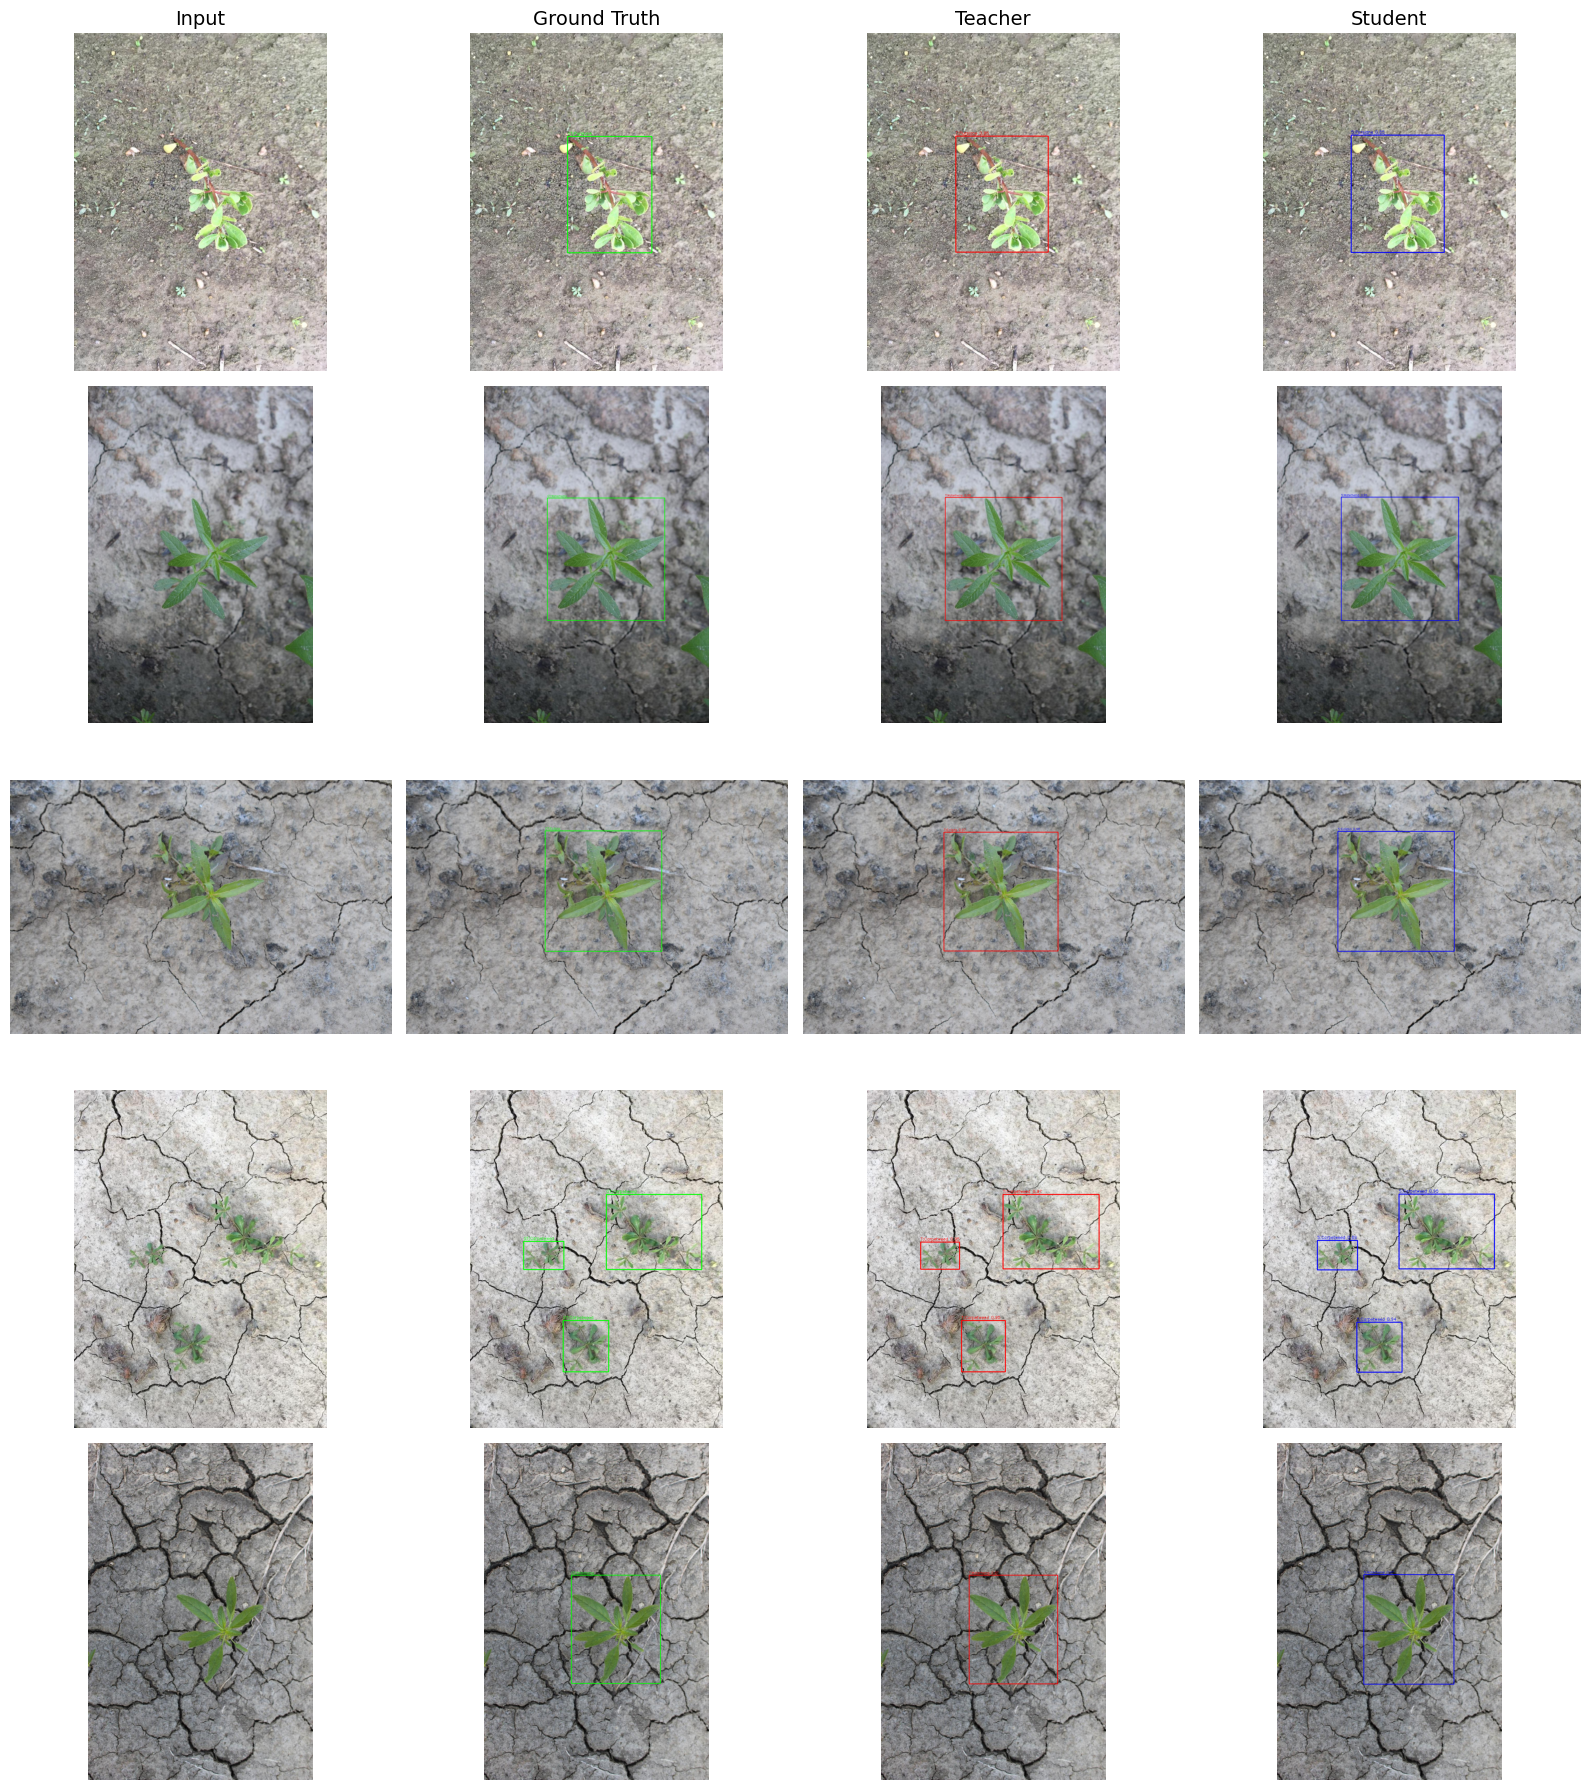

In [23]:
img = plot_grid(
    image_paths=image_paths,
    gt_paths=label_paths,
    teacher_preds=teacher_preds,
    student_preds=student_preds,
    class_names=data["names"]
)